# Importing Libraries

In [48]:
import numpy as np
import pandas as pd

# Installing Data

In [49]:
df = pd.read_csv("D:\Code\project_aiml\spam_classifire\spam.csv")
df.shape
df.sample(5)

,Category,Message
2221,ham,But really quite funny lor wat... Then u shd h...
3129,ham,would u fuckin believe it they didnt know i ha...
2440,ham,Rightio. 11.48 it is then. Well arent we all u...
1068,ham,Meeting u is my work. . . Tel me when shall i ...
3891,spam,Double Mins & 1000 txts on Orange tariffs. Lat...


# Data Cleaning

In [50]:
df.rename(columns={'Category': 'target','Message':'text'},inplace=True)
df.head(5)

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [51]:
from sklearn.preprocessing import LabelEncoder  
encoder = LabelEncoder()

df['target'] = encoder.fit_transform(df['target'])
df.head(5)

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [52]:
df = df.drop_duplicates(keep='first')
df.shape

(5157, 2)

# EDA

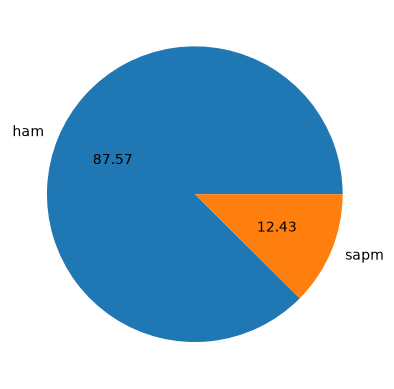

In [53]:
df['target'].value_counts()
import matplotlib.pyplot as plt

plt.pie(df['target'].value_counts() , labels=['ham' , 'sapm'] ,autopct= "%0.2f")

In [54]:
import nltk

nltk.download('punkt')
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\dabby\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\dabby\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [55]:
df['num_char'] = df['text'].apply(len)
df.head()

,target,text,num_char
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [56]:
# number of words

df['num_words'] = df['text'].apply(lambda x:len(nltk.word_tokenize(x)))
df.head(5)

,target,text,num_char,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [57]:
df['num_sent'] = df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))
df.head(5)

,target,text,num_char,num_words,num_sent
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [58]:
df[['num_char','num_words','num_sent']].describe()

,num_char,num_words,num_sent
count,5157.000000,5157.000000,5157.000000
mean,79.103936,18.560791,1.969750
std,58.382922,13.406330,1.455526
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,61.000000,15.000000,1.000000
75%,118.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [59]:
df[df['target'] == 0][['num_char','num_words','num_sent']].describe()

,num_char,num_words,num_sent
count,4516.000000,4516.000000,4516.000000
mean,70.869353,17.268158,1.827724
std,56.708301,13.588513,1.394338
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,53.000000,13.000000,1.000000
75%,91.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [60]:
df[df['target'] == 1][['num_char','num_words','num_sent']].describe()

,num_char,num_words,num_sent
count,641.000000,641.000000,641.000000
mean,137.118565,27.667707,2.970359
std,30.399707,7.103501,1.485575
min,7.000000,2.000000,1.000000
25%,130.000000,25.000000,2.000000
50%,148.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,223.000000,46.000000,9.000000


<Axes: xlabel='num_char', ylabel='Count'>

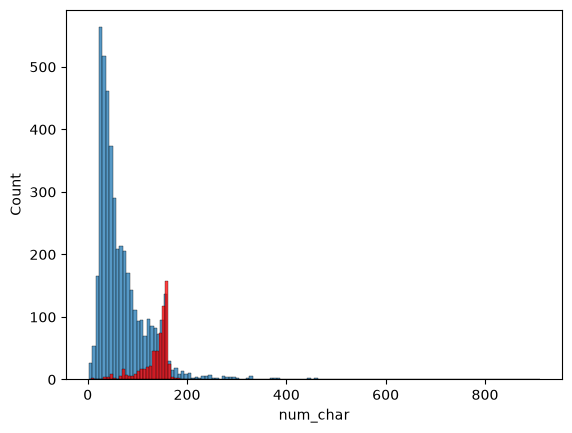

In [61]:
import seaborn as sns
plt.Figure(figsize=(12,6))
sns.histplot(df[df['target']==0]['num_char'])
sns.histplot(df[df['target']==1]['num_char'],color='red')

<Axes: xlabel='num_words', ylabel='Count'>

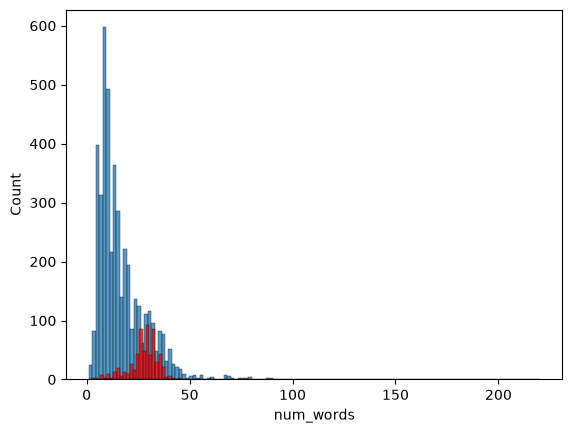

In [62]:
sns.histplot(df[df['target']==0]['num_words'])
sns.histplot(df[df['target']==1]['num_words'],color='red')

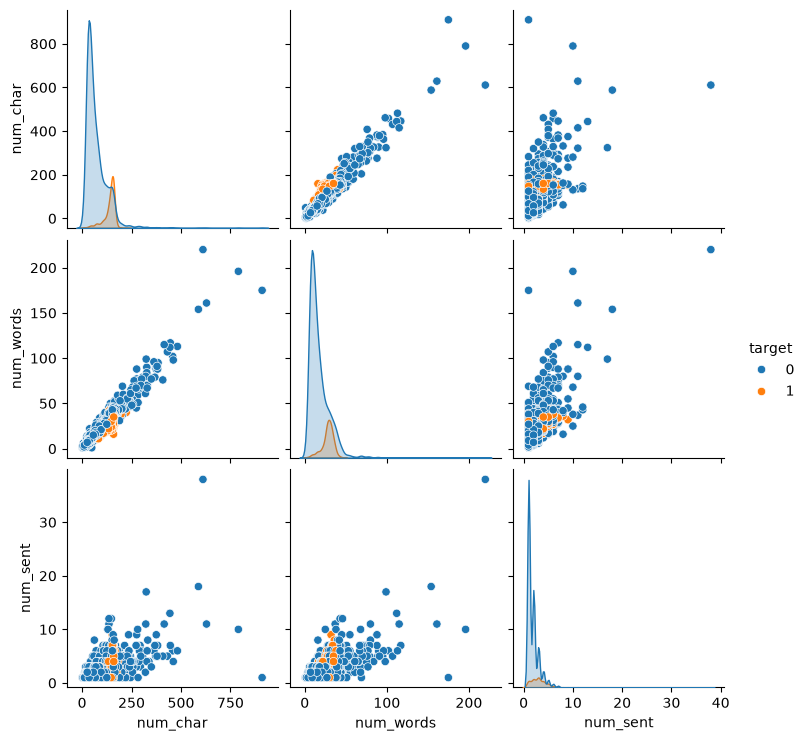

In [63]:
sns.pairplot(df,hue='target')

<Axes: >

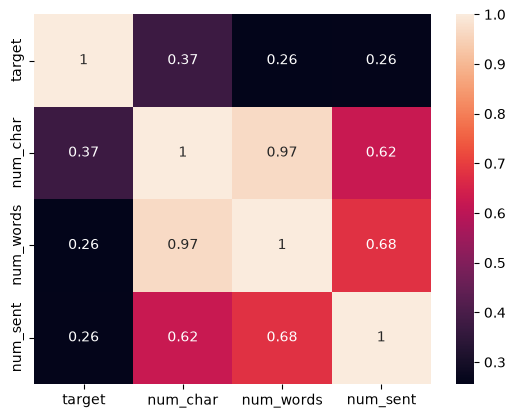

In [64]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

# Data Preprocessing

### Lower Case
### Tokenization
### Removing special characters
### Removing stop words and punctuations
### Stemming

In [65]:
from nltk.corpus import stopwords
import string

In [66]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('curling')

'curl'

In [67]:
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)

    # removing special character
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)
    text = y[:]
    y.clear()
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
    text = y[:]
    y.clear()

    for i in text:
        y.append(ps.stem(i))
    return " ".join(y)

In [68]:
transform_text("Hi HoW ARE ## YOu doing ?? yogesh is a")

'hi yogesh'

In [69]:
df['Transformed_text'] = df['text'].apply(transform_text)

In [70]:
df.head(5)

,target,text,num_char,num_words,num_sent,Transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [71]:
from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')

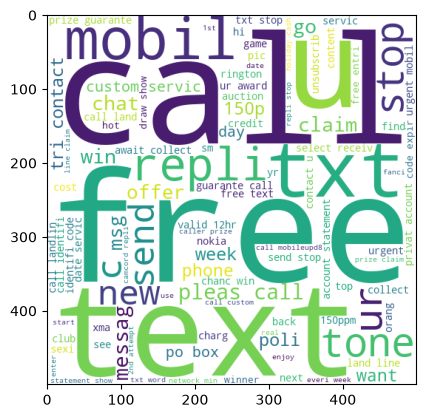

In [72]:
spam_wc = wc.generate(df[df['target'] == 1]['Transformed_text'].str.cat(sep=" "))
plt.imshow(spam_wc)

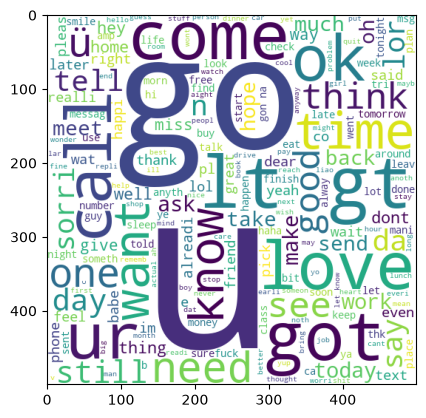

In [73]:
ham_wc = wc.generate(df[df['target'] == 0]['Transformed_text'].str.cat(sep=" "))
plt.imshow(ham_wc)

In [74]:
spam_corpus = []
for msg in df[df['target'] == 1]["Transformed_text"].tolist():
    for word in msg.split():
        spam_corpus.append(word)
len(spam_corpus)

9781

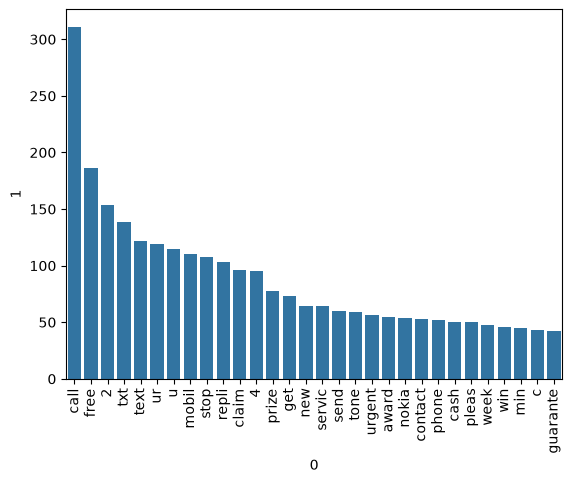

In [75]:
from collections import Counter

sns.barplot(x=pd.DataFrame(Counter(spam_corpus).most_common(30))[0], y=pd.DataFrame(Counter(spam_corpus).most_common(30))[1])
plt.xticks(rotation="vertical")
plt.show()

# Model building

In [113]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000)

X = tfidf.fit_transform(df["Transformed_text"]).toarray()
X.shape

(5157, 3000)

In [114]:
Y = df['target'].values
Y

array([0, 0, 1, ..., 0, 0, 0], shape=(5157,))

In [115]:
from sklearn.model_selection import train_test_split

X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=2)

In [116]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [117]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [95]:
gnb.fit(X_train,Y_train)
Y_pred1 = gnb.predict(X_test)
print(accuracy_score(Y_test,Y_pred1))
print(confusion_matrix(Y_test,Y_pred1))
print(precision_score(Y_test,Y_pred1))

# bad performation

0.8691860465116279
[[787 118]
 [ 17 110]]
0.4824561403508772


In [96]:
mnb.fit(X_train,Y_train)
Y_pred2 = mnb.predict(X_test)
print(accuracy_score(Y_test,Y_pred2))
print(confusion_matrix(Y_test,Y_pred2))
print(precision_score(Y_test,Y_pred2))

0.9612403100775194
[[905   0]
 [ 40  87]]
1.0


In [97]:
bnb.fit(X_train,Y_train)
Y_pred3 = bnb.predict(X_test)
print(accuracy_score(Y_test,Y_pred3))
print(confusion_matrix(Y_test,Y_pred3))
print(precision_score(Y_test,Y_pred3))

0.9718992248062015
[[902   3]
 [ 26 101]]
0.9711538461538461


## we choose tfidf --> mnb

In [118]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [119]:
svc = SVC(kernel='sigmoid',gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver="liblinear",penalty='11')
rfc = RandomForestClassifier(n_estimators=50,random_state=2)
abc = AdaBoostClassifier(n_estimators= 50 , random_state=2)
bc = BaggingClassifier(n_estimators= 50 , random_state=2)
etc = ExtraTreesClassifier(n_estimators= 50 , random_state=2)
gbdt = GradientBoostingClassifier(n_estimators= 50 , random_state=2)

In [120]:
clfs = {
    'SVC' : svc,
    'KN' : knc,
    'NB' : mnb,
    'DT' : dtc ,
    'RL' : rfc,
    "AdaBoost" : abc,
    'BgC': bc,
    'ETC' : etc,
    'GBDT' : gbdt
}

In [121]:
def trani_classifire(clf, X_train, Y_train, X_test, Y_test):
    # Changed .flt to .fit
    clf.fit(X_train, Y_train)
    Y_pred = clf.predict(X_test)
    accuracy = accuracy_score(Y_test, Y_pred)
    precision = precision_score(Y_test, Y_pred)
    
    return accuracy, precision

In [122]:
# This overwrites the lingering lists and brings the real functions back!
from sklearn.metrics import accuracy_score, precision_score

In [123]:
# Make these plural to protect the sklearn functions!
accuracy_scores = []
precision_scores = []

for name, clf in clfs.items():
    
    # Assuming trani_classifire is defined exactly this way earlier in your code
    current_accuracy, current_precision = trani_classifire(clf, X_train, Y_train, X_test, Y_test)
    
    print("For", name)
    print("Accuracy -", current_accuracy)
    print("Precision -", current_precision)

    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For SVC
Accuracy - 0.9777131782945736
Precision - 0.9905660377358491
For KN
Accuracy - 0.9127906976744186
Precision - 1.0
For NB
Accuracy - 0.9718992248062015
Precision - 1.0
For DT
Accuracy - 0.935077519379845
Precision - 0.8125
For RL
Accuracy - 0.9718992248062015
Precision - 1.0
For AdaBoost
Accuracy - 0.9302325581395349
Precision - 0.8666666666666667
For BgC
Accuracy - 0.9612403100775194
Precision - 0.8918918918918919
For ETC
Accuracy - 0.9777131782945736
Precision - 1.0
For GBDT
Accuracy - 0.9563953488372093
Precision - 0.9767441860465116


# so now NB is by far the best


In [124]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))